In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

In [ ]:
df=pd.read_csv(r"c:\Users\91939\Downloads\Sleep_health_and_lifestyle_dataset.csv")

Explore Data Set

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.shape

(374, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [6]:
df.dtypes


,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


In [7]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [8]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [9]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


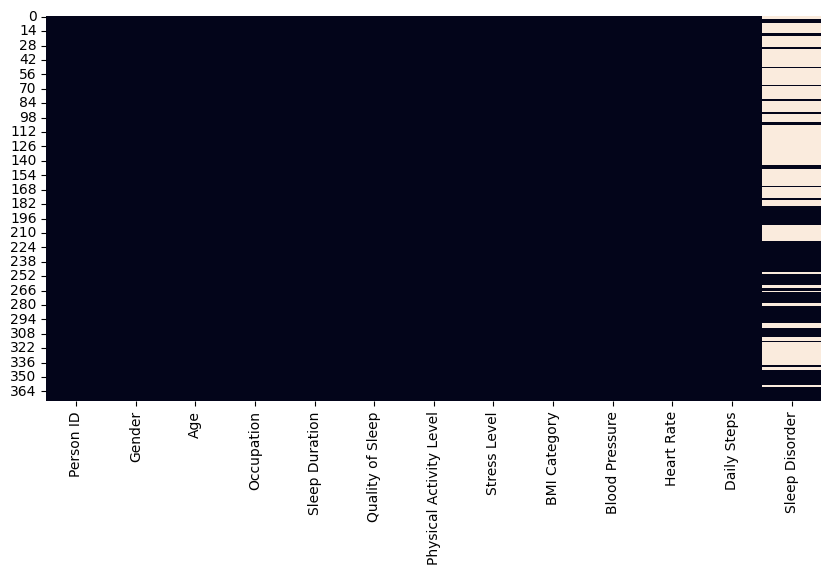

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [12]:
df['Sleep Disorder'] = df['Sleep Disorder'].replace({None: "Normal"})

In [13]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

print(missing)

                         Missing Values  Percentage
Person ID                             0         0.0
Gender                                0         0.0
Age                                   0         0.0
Occupation                            0         0.0
Sleep Duration                        0         0.0
Quality of Sleep                      0         0.0
Physical Activity Level               0         0.0
Stress Level                          0         0.0
BMI Category                          0         0.0
Blood Pressure                        0         0.0
Heart Rate                            0         0.0
Daily Steps                           0         0.0
Sleep Disorder                        0         0.0


In [14]:
missing[missing['Missing Values']>0]

,Missing Values,Percentage


In [15]:
df[df.isnull().any(axis=1)].index

Index([], dtype='int64')

In [16]:
df.drop("Person ID",axis=1,inplace=True)

# **EDA**

In [17]:
df['BMI Category'].value_counts()

,count
BMI Category,
Normal,195
Overweight,148
Normal Weight,21
Obese,10


In [18]:
df['BMI Category'] = df['BMI Category'].replace("Normal Weight", "Normal")

In [19]:
df['BMI Category'].value_counts()

,count
BMI Category,
Normal,216
Overweight,148
Obese,10


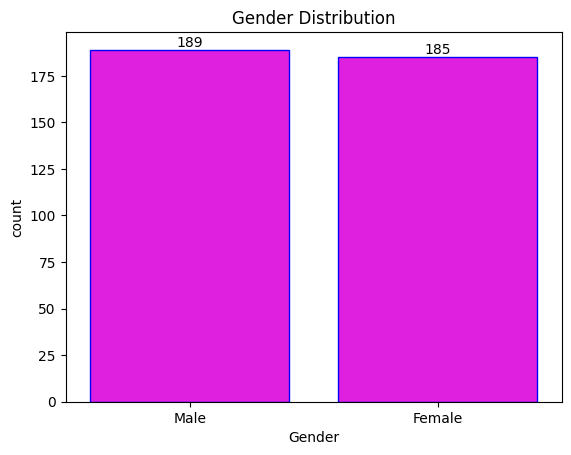

In [20]:
ax=sns.countplot(x=df["Gender"],edgecolor='b',color="magenta")
ax.set_title("Gender Distribution")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

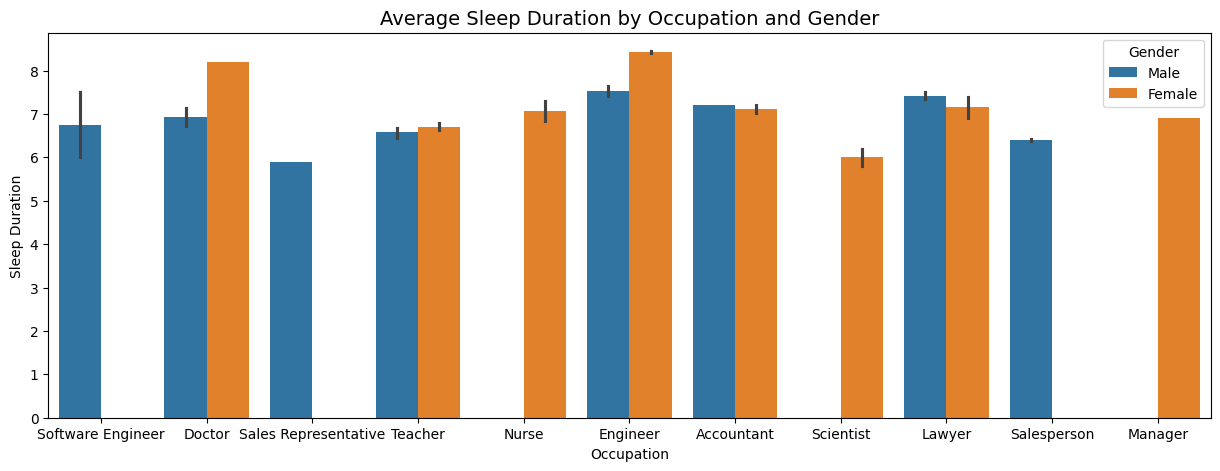

In [21]:
plt.figure(figsize=(15,5))
sns.barplot(x="Occupation",y="Sleep Duration",hue="Gender",data=df)
plt.title("Average Sleep Duration by Occupation and Gender", fontsize=14)
plt.show()

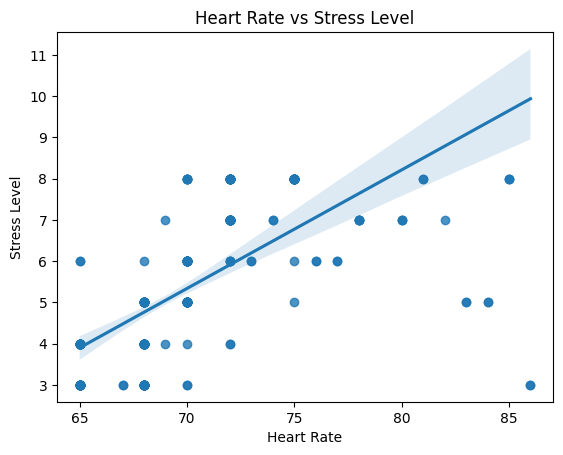

In [22]:
sns.regplot(x=df["Heart Rate"],y=df["Stress Level"])
plt.title("Heart Rate vs Stress Level")
plt.show()

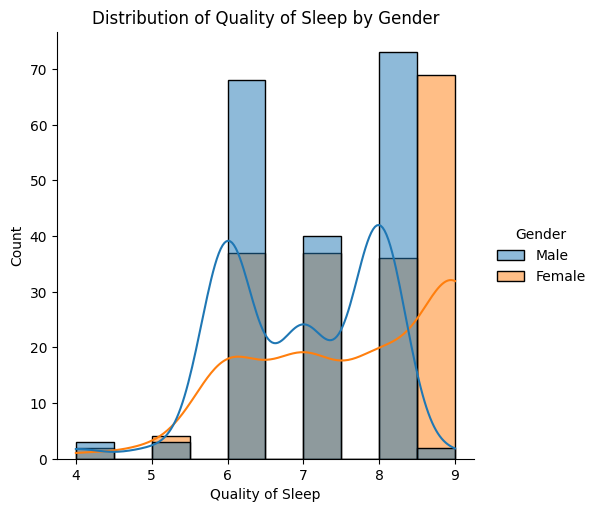

In [23]:
sns.displot(x='Quality of Sleep',hue='Gender',kde=True,data=df)
plt.title("Distribution of Quality of Sleep by Gender")
plt.show()

In [24]:
df.groupby(["Sleep Disorder",'Gender'])['Physical Activity Level'].mean()

Sleep Disorder  Gender
Insomnia        Female    45.000000
                Male      48.414634
Normal          Female    50.146341
                Male      62.620438
Sleep Apnea     Female    77.746269
                Male      56.818182
Name: Physical Activity Level, dtype: float64

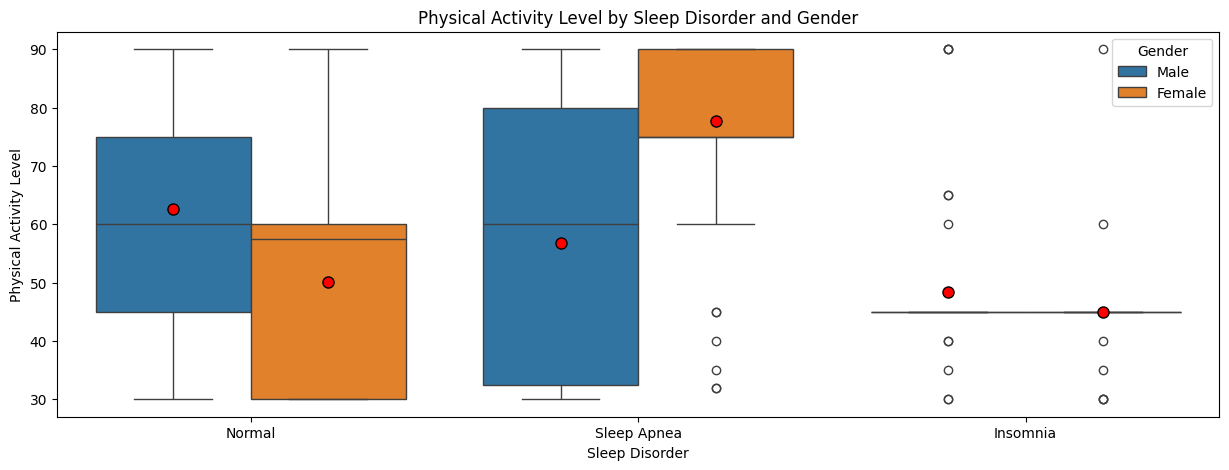

In [25]:
plt.figure(figsize=(15,5))
sns.boxplot(x='Sleep Disorder',y='Physical Activity Level',hue='Gender',data=df,showmeans=True,meanprops={"marker": "o","markerfacecolor": "red",
                                                                                                          "markeredgecolor": "black",
                                                                                                          "markersize": 8
                                                                                                         }
           )
plt.title("Physical Activity Level by Sleep Disorder and Gender")
plt.show()

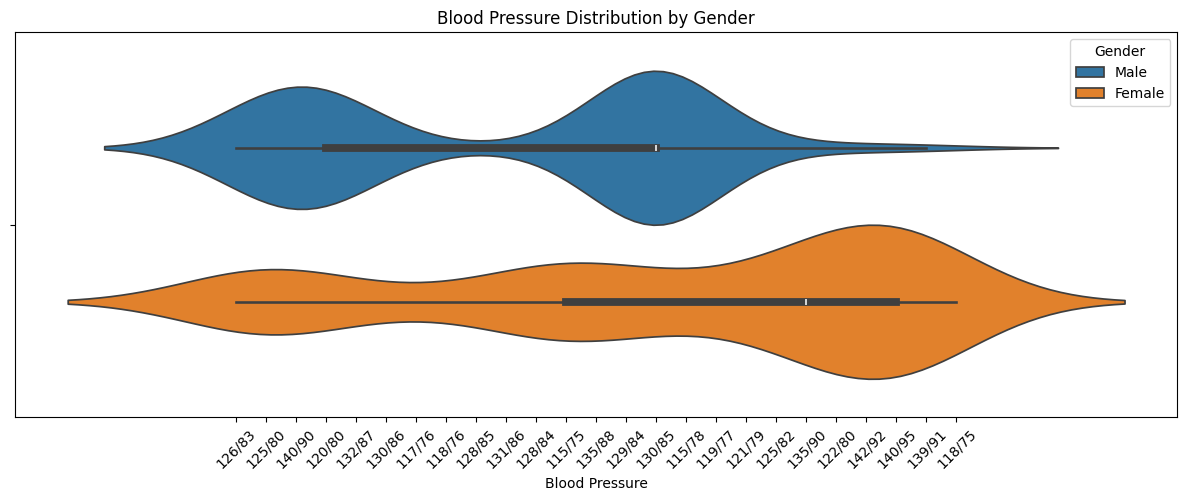

In [26]:
plt.figure(figsize=(15,5))
sns.violinplot(x=df['Blood Pressure'],hue=df["Gender"])
plt.xticks(rotation=45)
plt.title("Blood Pressure Distribution by Gender")
plt.show()

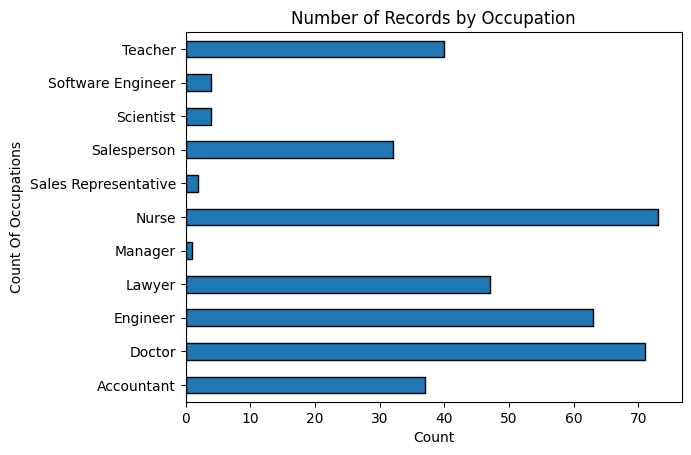

In [27]:
df.groupby(["Occupation"])['Sleep Disorder'].count().plot(kind='barh',edgecolor="black")
plt.xlabel("Count")
plt.ylabel("Count Of Occupations")
plt.title("Number of Records by Occupation")
plt.show()

In [28]:
df.groupby(["Occupation",'BMI Category'])['BMI Category'].count()

Occupation            BMI Category
Accountant            Normal          31
                      Overweight       6
Doctor                Normal          67
                      Obese            4
Engineer              Normal          60
                      Overweight       3
Lawyer                Normal          43
                      Obese            2
                      Overweight       2
Manager               Overweight       1
Nurse                 Normal           7
                      Overweight      66
Sales Representative  Obese            2
Salesperson           Overweight      32
Scientist             Overweight       4
Software Engineer     Normal           2
                      Obese            1
                      Overweight       1
Teacher               Normal           6
                      Obese            1
                      Overweight      33
Name: BMI Category, dtype: int64

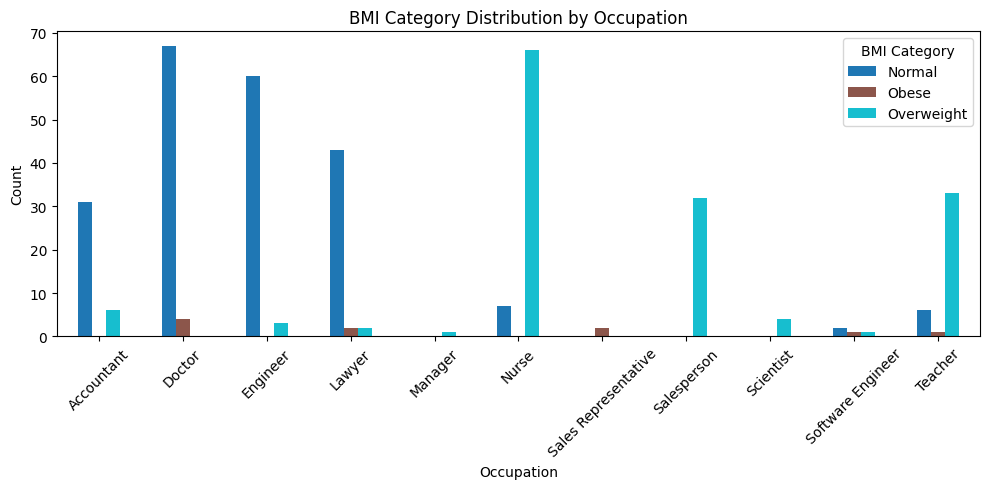

In [29]:
df.groupby(["Occupation", "BMI Category"])["BMI Category"].count().unstack().plot(kind="bar", figsize=(10,5),cmap='tab10')
plt.title("BMI Category Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="BMI Category",loc="best")
plt.tight_layout()
plt.show()


In [30]:
df["Occupation"].value_counts(normalize=True)*100

,proportion
Occupation,
Nurse,19.518717
Doctor,18.983957
Engineer,16.844920
Lawyer,12.566845
Teacher,10.695187
Accountant,9.893048
Salesperson,8.556150
Scientist,1.069519
Software Engineer,1.069519


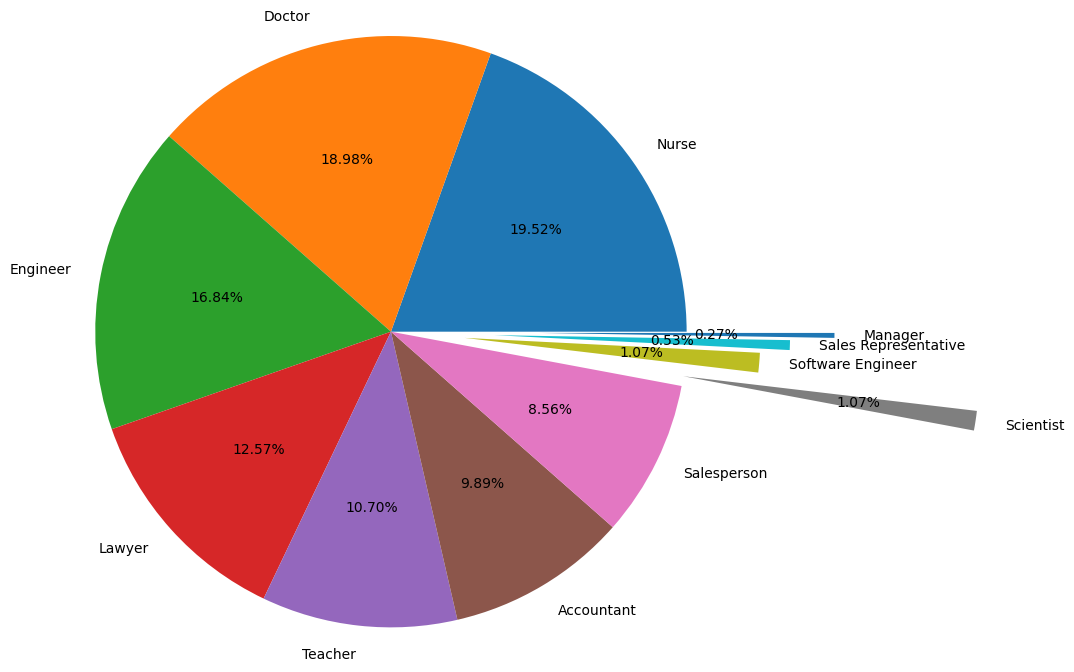

In [31]:
counts = df["Occupation"].value_counts()

counts.plot(
    kind="pie",
    labels=counts.index,
    autopct="%0.2f%%",
    explode=[0,0,0,0,0,0,0,2,0.5,0.7,1],
    radius=2
)

plt.ylabel('')

plt.show()

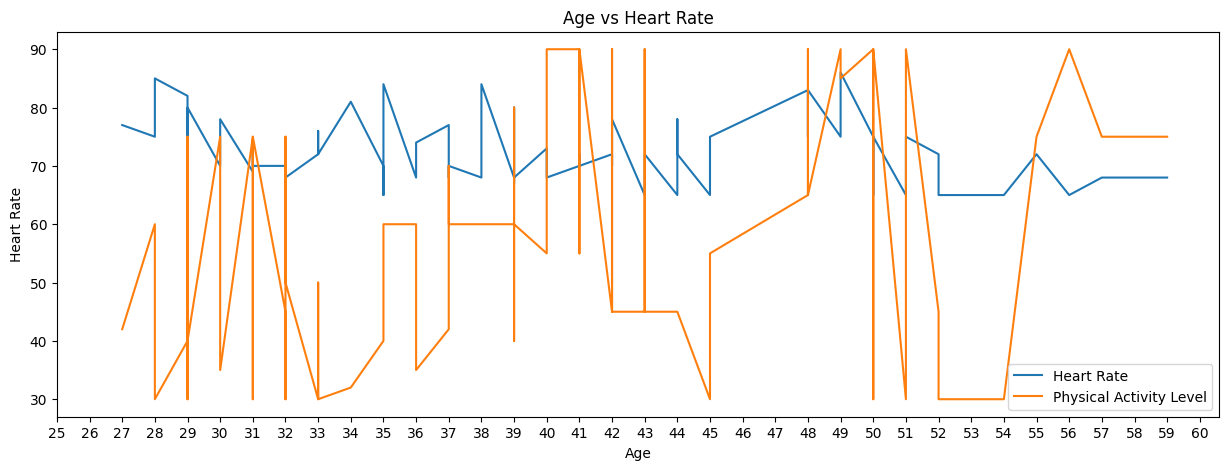

In [32]:
plt.figure(figsize=(15,5))
plt.plot(df["Age"], df["Heart Rate"],label="Heart Rate")
plt.plot(df['Age'],df['Physical Activity Level'],label="Physical Activity Level")
plt.xticks([i for i in range(25, 61)])
plt.xlabel("Age")
plt.ylabel("Heart Rate")
plt.title("Age vs Heart Rate")
plt.legend(loc="best")
plt.show()

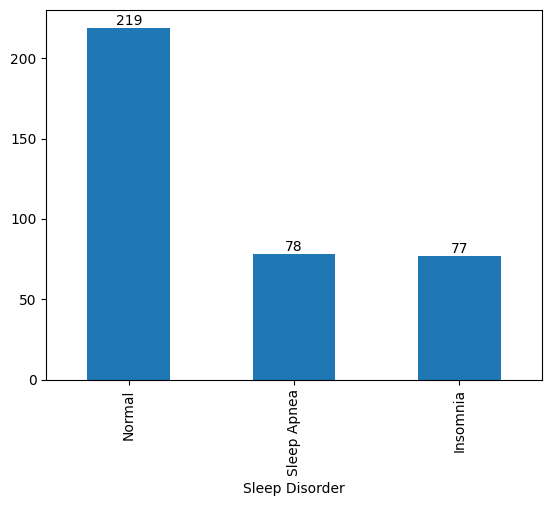

In [33]:
ax=df["Sleep Disorder"].value_counts().plot(kind="bar")
for col in ax.containers:
    ax.bar_label(col)
plt.show()


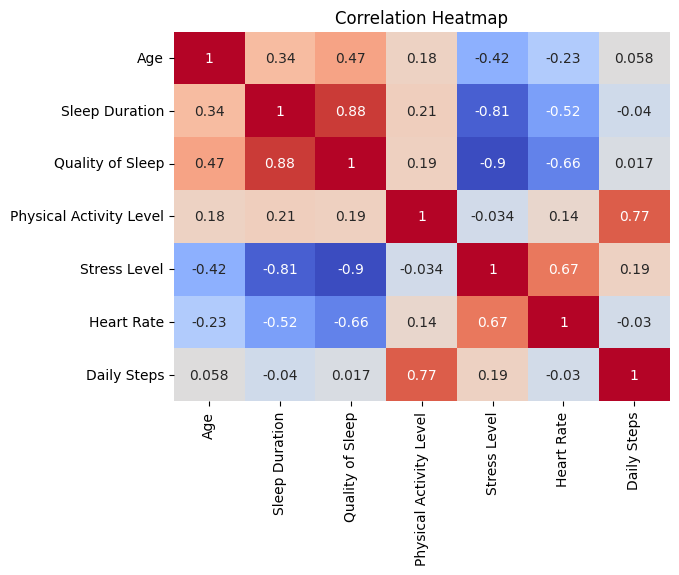

In [34]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cbar=False,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# **Handling Outliers**

In [35]:
numeric_cols = df.select_dtypes(include="number")

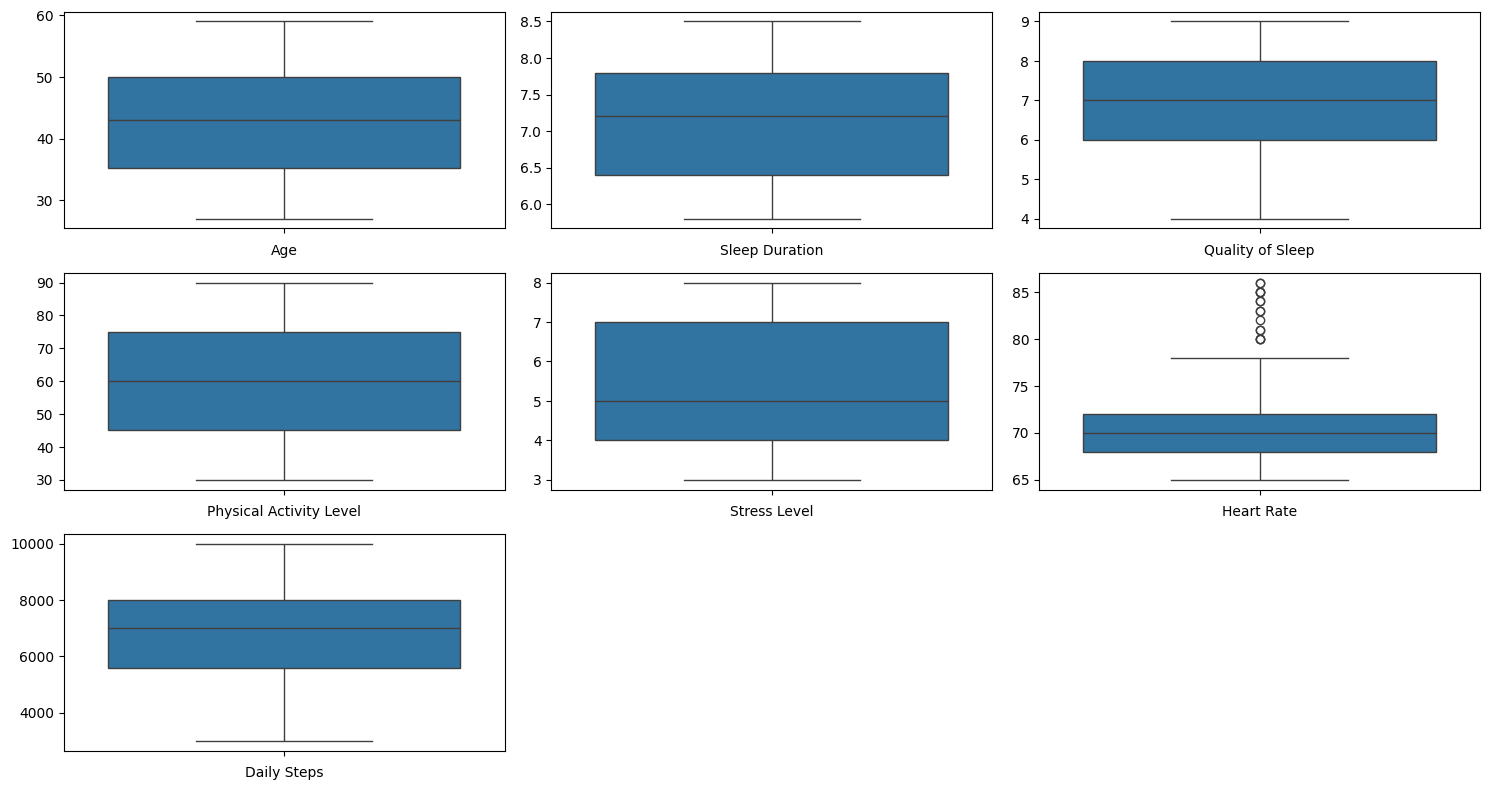

In [36]:
plt.figure(figsize=(15,8))
i=1
for cols in numeric_cols:
    plt.subplot(3,3,i)
    sns.boxplot(df[cols])
    plt.xlabel(cols)
    plt.ylabel("")
    plt.tight_layout()
    i+=1
plt.show()



In [37]:
q1=df["Heart Rate"].quantile(0.25)
q3=df["Heart Rate"].quantile(0.75)
iqr=q3-q1
lower = q1-1.5*iqr
upper=q3+1.5*iqr
df["Heart Rate"]=df["Heart Rate"].clip(lower,upper)

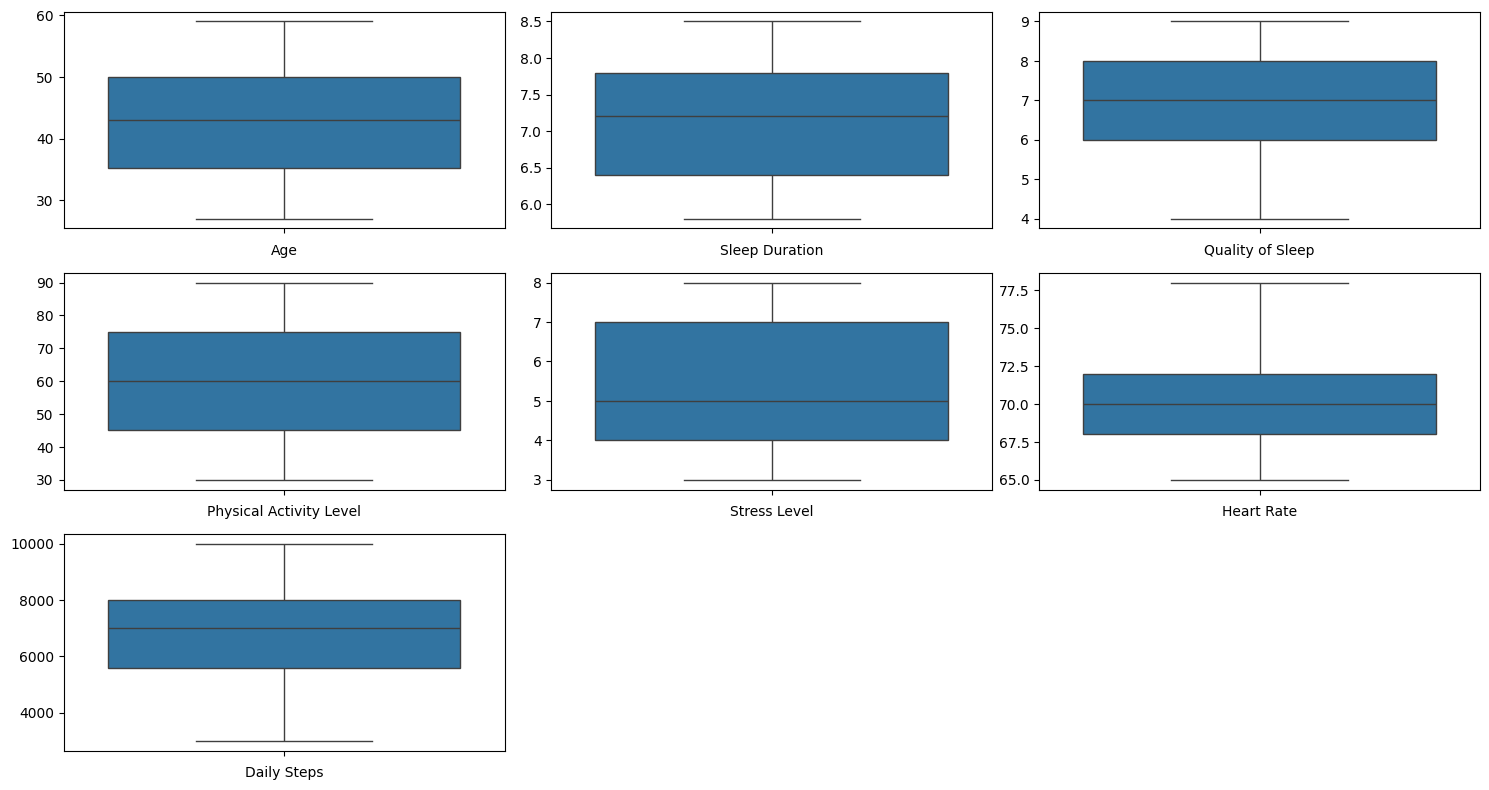

In [38]:
plt.figure(figsize=(15,8))
i=1
for cols in numeric_cols:
    plt.subplot(3,3,i)
    sns.boxplot(df[cols])
    plt.xlabel(cols)
    plt.ylabel("")
    plt.tight_layout()
    i+=1
plt.show()

# **Encoding**

In [39]:
categorical_col = ['Gender','Occupation','BMI Category','Blood Pressure']

In [40]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in categorical_col:
    df[col]=le.fit_transform(df[col])

In [41]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,27,9,6.1,6,42,6,2,11,77,4200,Normal
1,1,28,1,6.2,6,60,8,0,9,75,10000,Normal
2,1,28,1,6.2,6,60,8,0,9,75,10000,Normal
3,1,28,6,5.9,4,30,8,1,22,78,3000,Sleep Apnea
4,1,28,6,5.9,4,30,8,1,22,78,3000,Sleep Apnea


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import  train_test_split
from sklearn.metrics import accuracy_score,roc_curve,roc_auc_score,auc,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV


In [43]:
x=df.drop("Sleep Disorder",axis=1)
y=df["Sleep Disorder"]

In [44]:
x_train,x_test,y_train,y_test = train_test_split(x,y,stratify=y,test_size=0.2,random_state=42)

In [45]:
x_train,y_train = SMOTE(random_state=20).fit_resample(x_train,y_train)

In [46]:
model = RandomForestClassifier()

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [50, 100,150, 200, 300, 500],
    "max_depth": [None, 1, 3, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"],
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=120,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=120, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 1, 3, 5, 10, 20,
                                                      30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200, 300,
                                                         500]},
                   random_state=42, scoring='accuracy', verbose=2)

In [48]:
h3_model_rf = random_search.best_estimator_

In [49]:
y_pred_h3_rf = h3_model_rf.predict(x_test)

In [50]:
random_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20,
 'criterion': 'entropy'}

In [51]:
print(f"Train Accuracy : {h3_model_rf.score(x_train,y_train):.2f}")
print(f"Test Accuracy : {accuracy_score(y_test,y_pred_h3_rf):.2f}")
print(confusion_matrix(y_test,y_pred_h3_rf))
print(classification_report(y_test,y_pred_h3_rf))

Train Accuracy : 0.95
Test Accuracy : 0.96
[[13  0  2]
 [ 0 44  0]
 [ 1  0 15]]
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
      Normal       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75



In [52]:
classes = h3_model_rf.classes_
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities for each class
y_pred_proba = h3_model_rf.predict_proba(x_test)

# Dictionary to store ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

for i in range(len(classes)):
    print(f"{classes[i]} AUC = {roc_auc[i]:.3f}")

Insomnia AUC = 0.979
Normal AUC = 1.000
Sleep Apnea AUC = 0.990


In [53]:
# Evaluation for Model H3
y_pred_proba_h3 = h3_model_rf.predict_proba(x_test)
roc_auc_h3 = roc_auc_score(
    y_test,
    y_pred_proba_h3,
    multi_class='ovr',
    average='macro'
)

print(f"Random Forest (H3) ROC-AUC: {roc_auc_h3:.4f}")

Random Forest (H3) ROC-AUC: 0.9898


In [54]:

# Create Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform Cross Validation
cv_scores = cross_val_score(
    h3_model_rf,
    x_train,
    y_train,
    cv=skf,
    scoring='accuracy'
)


In [55]:
# Descriptive printing for Cross Validation results (H3)
print("Model H3 Cross Validation Scores:", cv_scores)
print(f"Model H3 Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Model H3 CV Standard Deviation: {cv_scores.std():.4f}")

Model H3 Cross Validation Scores: [0.87619048 0.91428571 0.92380952 0.9047619  0.8952381 ]
Model H3 Mean CV Accuracy: 0.9029
Model H3 CV Standard Deviation: 0.0164
